# Bulk-Loading SQL Server from Python — Benchmark

## 1. Infrastructure Setup

In [1]:
# copy env file if it doesn't exist yet
import shutil, os
if not os.path.exists('.env'):
    shutil.copy('.env.example', '.env')
    print('created .env from .env.example — edit it if your SQL Server config differs')
else:
    print('.env already exists')

.env already exists


In [2]:
# start sql server container
!docker-compose up -d

 Container sqlserver_container  Recreate
 Container sqlserver_container  Recreated
 Container sqlserver_container  Starting
Error response from daemon: failed to set up container networking: driver failed programming external connectivity on endpoint sqlserver_container (5958c731660353302d88dd7ead01852aae09f4ae57061ffd7555cad18501c887): Bind for 0.0.0.0:1433 failed: port is already allocated


In [3]:
# wait for sql server to be ready
import time
print('waiting 30s for SQL Server to start...')
time.sleep(30)
print('done')

waiting 30s for SQL Server to start...


done


In [4]:
# create database, table, TVP type, and stored proc
from db_setup import setup_all
setup_all()

database 'benchmark_db' ready


table 'bench_bulk' created
TVP type 'BulkLoadType' created
stored proc 'usp_insert_bulk_tvp' created

all set — ready to benchmark


## 2. Imports

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100

## 3. Test Data

In [6]:
from test_data import make_test_df

sample = make_test_df(5)
display(sample)
print(f'\ndtypes:\n{sample.dtypes}')

,id,value,amount,category,description,created_at
0,1,0.304717,5265,cat_15,item_0_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx...,2024-08-23 00:15:30
1,2,-1.039984,9756,cat_10,item_1_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx,2024-05-26 21:08:59
2,3,0.750451,7357,cat_2,item_2_xxxxxxxxxxxxxxxxxxxxxx,2024-10-27 07:23:30
3,4,0.940565,7611,cat_16,item_3_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx...,2024-07-18 01:57:32
4,5,-1.951035,7175,cat_9,item_4_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx...,2024-06-10 20:18:30



dtypes:
id                      int32
value                 float64
amount                  int32
category               object
description            object
created_at     datetime64[ns]
dtype: object


## 4. Load Benchmark Results

In [7]:
tier1 = pd.read_csv('results/tier1_all_methods.csv')
tier2 = pd.read_csv('results/tier2_fast_1M.csv')
tier3 = pd.read_csv('results/tier3_top_10M.csv')

results = pd.concat([tier1, tier2, tier3], ignore_index=True)
valid = results.dropna(subset=['mean_sec'])

print(f'loaded {len(valid)} data points across {valid["method"].nunique()} methods')
print(f'row counts: {sorted(valid["rows"].unique().astype(int))}')
print(f'failed runs: {len(results) - len(valid)}')

loaded 48 data points across 13 methods
row counts: [np.int64(1000), np.int64(10000), np.int64(100000), np.int64(1000000), np.int64(10000000)]
failed runs: 5


In [8]:
display(
    valid[['method', 'rows', 'median_sec', 'rows_per_sec']]
    .sort_values(['rows', 'median_sec'])
    .reset_index(drop=True)
    .style.format({'median_sec': '{:.4f}', 'rows_per_sec': '{:,.0f}', 'rows': '{:,.0f}'})
)

,method,rows,median_sec,rows_per_sec
0,tvp_pyodbc,"1,000",0.0139,"72,031"
1,arrowsqlbcpy,"1,000",0.0375,"26,686"
2,sa_to_sql_fast_executemany,"1,000",0.0533,"18,762"
3,pyodbc_fast_executemany,"1,000",0.0577,"17,327"
4,mssql_python_executemany,"1,000",0.0610,"16,402"
5,sa_core_executemany,"1,000",0.0616,"16,233"
6,sa_to_sql_default,"1,000",0.0630,"15,883"
7,bulk_insert_tsql,"1,000",0.0864,"11,580"
8,bcp_cli,"1,000",0.1031,"9,700"
9,sa_to_sql_multi,"1,000",0.1447,"6,912"


## 5. All Methods — 10K Rows

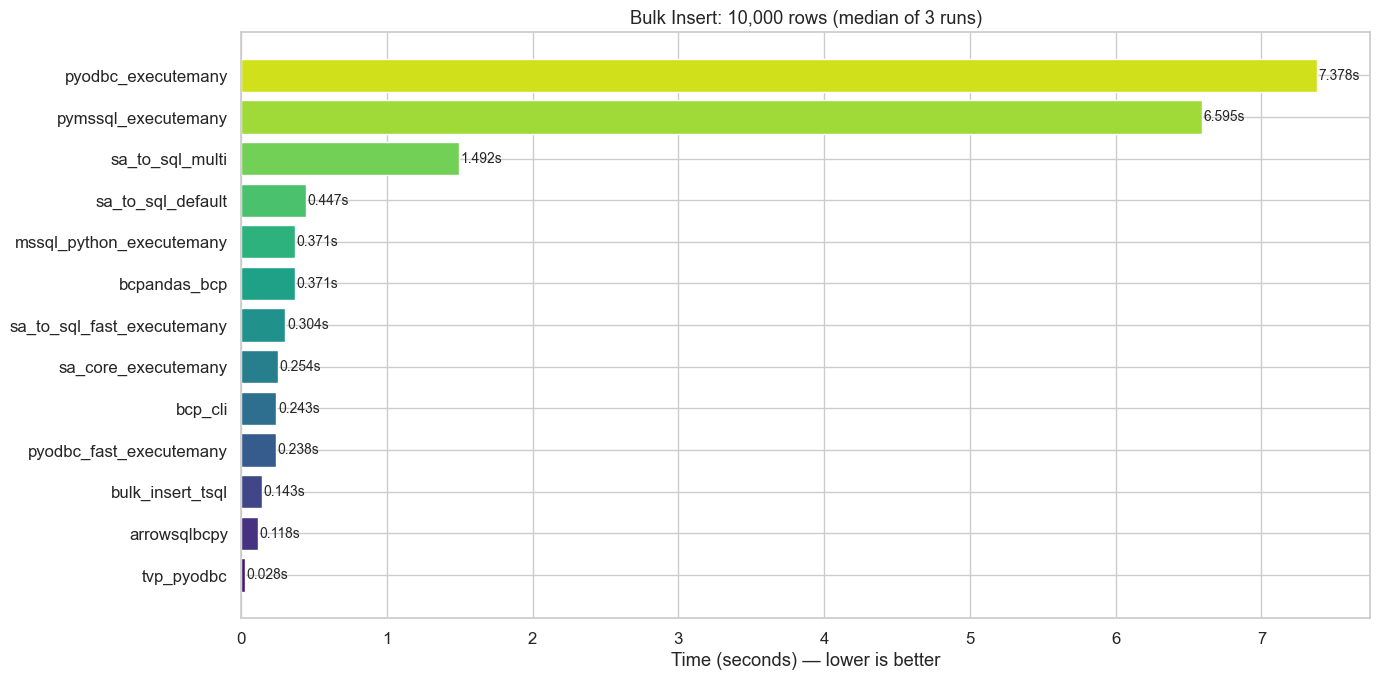

In [9]:
df_10k = results[results['rows'] == 10_000].dropna(subset=['median_sec']).copy()
df_10k = df_10k.sort_values('median_sec')

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(df_10k['method'], df_10k['median_sec'], color=sns.color_palette('viridis', len(df_10k)))
ax.set_xlabel('Time (seconds) — lower is better')
ax.set_title('Bulk Insert: 10,000 rows (median of 3 runs)')

for bar, val in zip(bars, df_10k['median_sec']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/bulk_insert_10k.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Scaling Curves (1K — 10M)

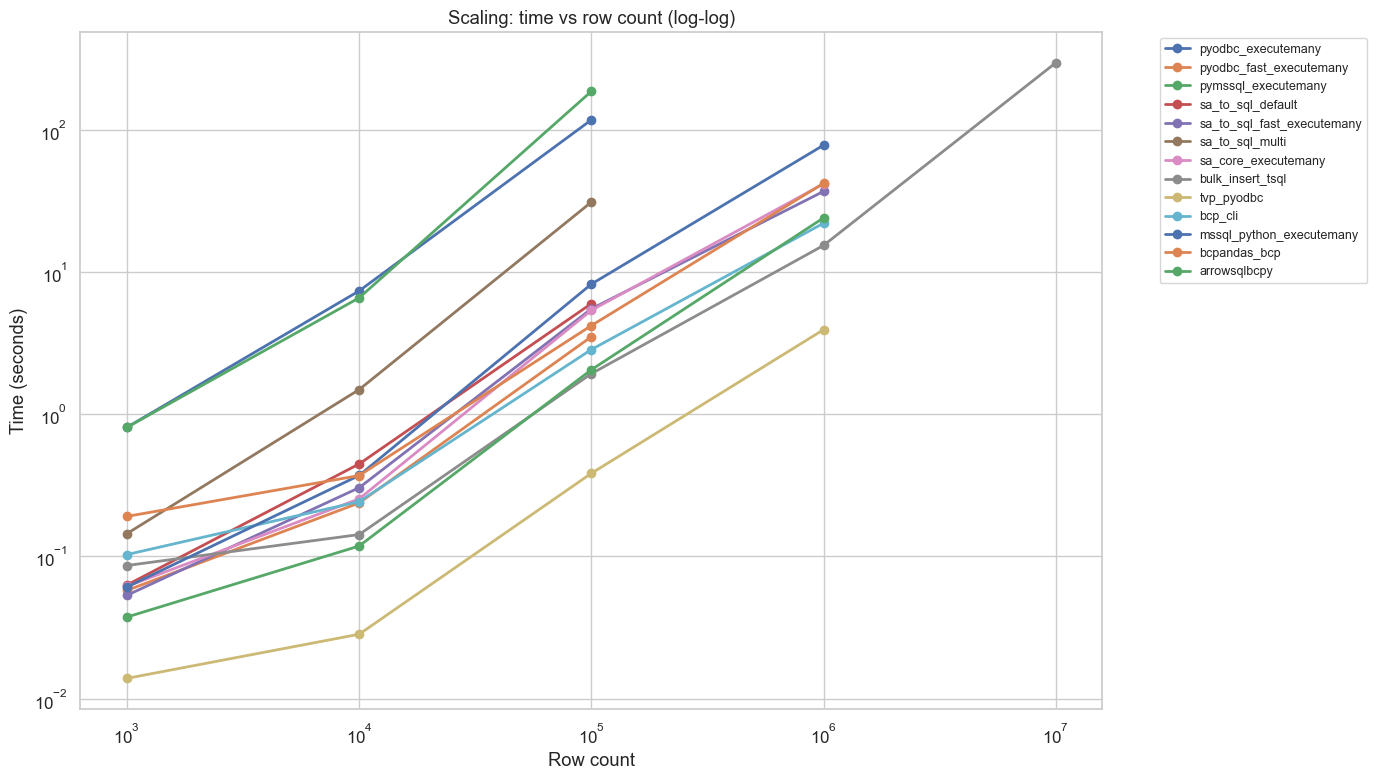

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))
for method in valid['method'].unique():
    subset = valid[valid['method'] == method].sort_values('rows')
    ax.plot(subset['rows'], subset['median_sec'], marker='o', label=method, linewidth=2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Row count')
ax.set_ylabel('Time (seconds)')
ax.set_title('Scaling: time vs row count (log-log)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('results/scaling_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Throughput — Tier 1

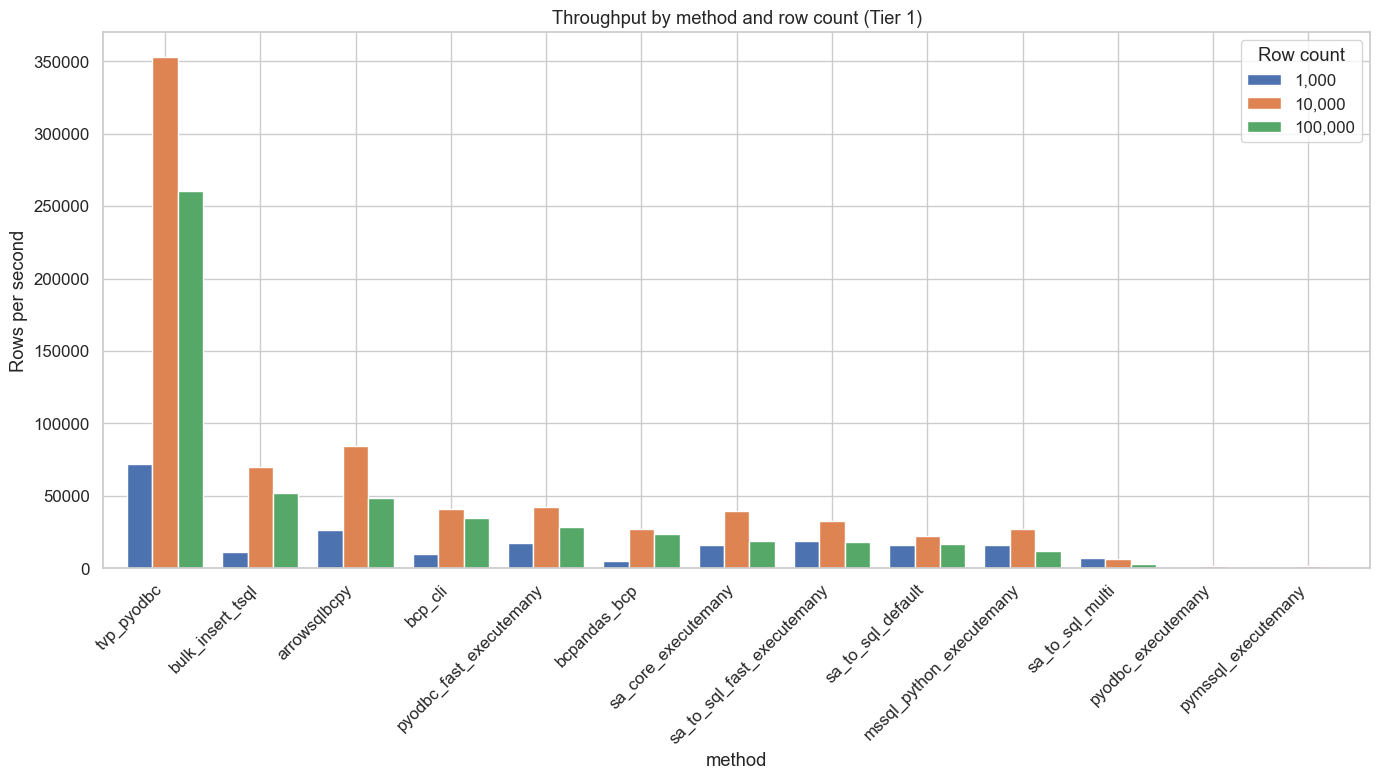

In [11]:
t1_throughput = valid[valid['rows'] <= 100_000].copy()

pivot = t1_throughput.pivot_table(index='method', columns='rows', values='rows_per_sec')
pivot = pivot.sort_values(pivot.columns[-1], ascending=False)
pivot.columns = [f'{int(c):,}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 8))
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Rows per second')
ax.set_title('Throughput by method and row count (Tier 1)')
ax.legend(title='Row count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/throughput.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Speedup vs Baseline (100K Rows)

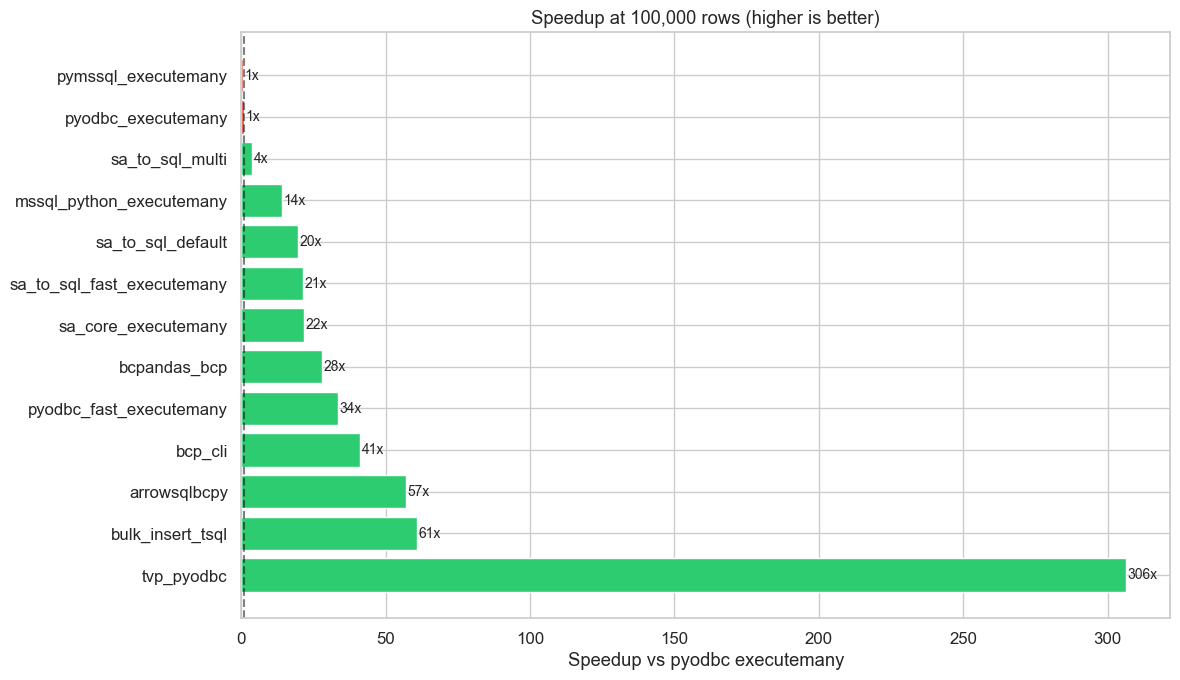

In [12]:
speedup_rows = []
for n in valid['rows'].unique():
    subset = valid[valid['rows'] == n]
    baseline_row = subset[subset['method'] == 'pyodbc_executemany']
    if baseline_row.empty:
        continue
    baseline = baseline_row['median_sec'].values[0]
    for _, row in subset.iterrows():
        speedup_rows.append({
            'method': row['method'],
            'rows': int(n),
            'speedup': baseline / row['median_sec'] if row['median_sec'] > 0 else 0,
        })

speedup_df = pd.DataFrame(speedup_rows)
sp_100k = speedup_df[speedup_df['rows'] == 100_000].sort_values('speedup', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if s > 1 else '#e74c3c' for s in sp_100k['speedup']]
ax.barh(sp_100k['method'], sp_100k['speedup'], color=colors)
ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Speedup vs pyodbc executemany')
ax.set_title('Speedup at 100,000 rows (higher is better)')

for i, (_, row) in enumerate(sp_100k.iterrows()):
    ax.text(row['speedup'] + 0.5, i, f"{row['speedup']:.0f}x", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/speedup_100k.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Table

In [13]:
summary = valid.pivot_table(
    index='method', columns='rows', values='median_sec', aggfunc='first'
).round(4)
summary.columns = [f'{int(c):,} rows' for c in summary.columns]

display(
    summary.sort_values(summary.columns[0], na_position='last')
    .style.format('{:.4f}', na_rep='\u2014')
    .set_caption('Median time in seconds')
)

,"1,000 rows","10,000 rows","100,000 rows","1,000,000 rows","10,000,000 rows"
method,,,,,
tvp_pyodbc,0.0139,0.0284,0.3844,3.9398,—
arrowsqlbcpy,0.0375,0.1184,2.0573,24.0955,—
sa_to_sql_fast_executemany,0.0533,0.3045,5.5192,36.9984,—
pyodbc_fast_executemany,0.0577,0.2380,3.5125,—,—
mssql_python_executemany,0.0610,0.3713,8.2384,78.2116,—
sa_core_executemany,0.0616,0.2542,5.3893,41.7728,—
sa_to_sql_default,0.0630,0.4474,6.0063,—,—
bulk_insert_tsql,0.0864,0.1426,1.9304,15.4218,297.2065
bcp_cli,0.1031,0.2430,2.8549,22.0977,—


## 10. Tier 2 — 1M Rows

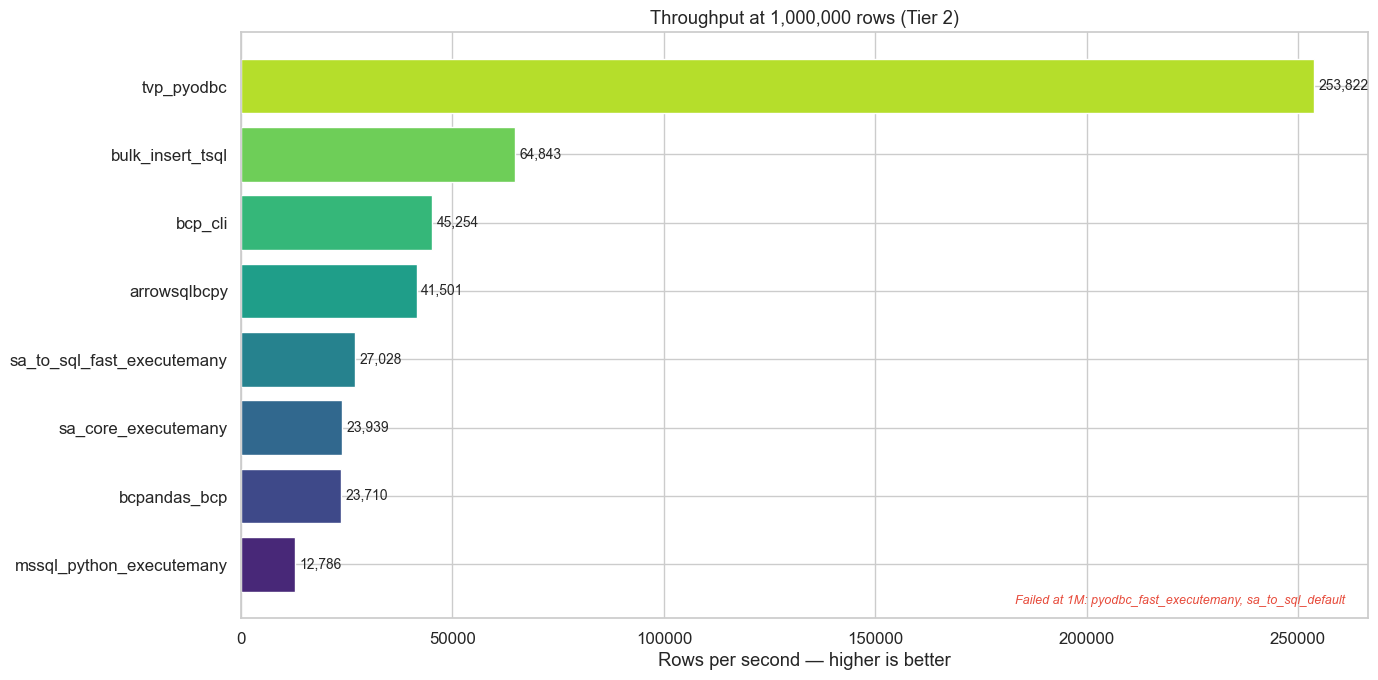

In [14]:
t2 = results[results['rows'] == 1_000_000].copy()
succeeded = t2.dropna(subset=['median_sec']).sort_values('rows_per_sec')
failed = t2[t2['median_sec'].isna()]

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(succeeded['method'], succeeded['rows_per_sec'],
               color=sns.color_palette('viridis', len(succeeded)))
ax.set_xlabel('Rows per second — higher is better')
ax.set_title('Throughput at 1,000,000 rows (Tier 2)')

for bar, val in zip(bars, succeeded['rows_per_sec']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=10)

if not failed.empty:
    ax.text(0.98, 0.02, f"Failed at 1M: {', '.join(failed['method'])}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, style='italic', color='#e74c3c')

plt.tight_layout()
plt.savefig('results/throughput_1M.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Tier 3 — 10M Rows

In [15]:
t3 = results[results['rows'] == 10_000_000].copy()
survived = t3.dropna(subset=['median_sec'])
failed_10m = t3[t3['median_sec'].isna()]

print('10M row results:')
print(f'  Survived: {", ".join(survived["method"])}')
print(f'  Failed:   {", ".join(failed_10m["method"])}')
print()
for _, row in survived.iterrows():
    print(f'  {row["method"]}:')
    print(f'    Median time:   {row["median_sec"]:.1f} seconds')
    print(f'    Rows/sec:      {row["rows_per_sec"]:,.0f}')
    print(f'    Range:         {row["min_sec"]:.1f}s \u2014 {row["max_sec"]:.1f}s')

10M row results:
  Survived: bulk_insert_tsql
  Failed:   tvp_pyodbc, bcp_cli, arrowsqlbcpy

  bulk_insert_tsql:
    Median time:   297.2 seconds
    Rows/sec:      33,647
    Range:         265.0s — 329.4s


## 12. Re-run Benchmarks (optional)

In [16]:
# uncomment and run to re-execute benchmarks from scratch
# this takes a while, especially at 1M and 10M tiers

# from methods import (
#     insert_pyodbc_executemany, insert_pyodbc_fast_executemany,
#     insert_pymssql_executemany, insert_sa_to_sql_default,
#     insert_sa_to_sql_fast, insert_sa_to_sql_multi,
#     insert_sa_core_executemany, insert_bulk_insert_tsql,
#     insert_bcp_cli, insert_tvp_pyodbc, insert_bcpandas,
# )
# from timing import run_benchmark_suite, save_results
# import db_setup
#
# all_methods = {
#     'pyodbc_executemany': insert_pyodbc_executemany,
#     'pyodbc_fast_executemany': insert_pyodbc_fast_executemany,
#     'pymssql_executemany': insert_pymssql_executemany,
#     'sa_to_sql_default': insert_sa_to_sql_default,
#     'sa_to_sql_fast': insert_sa_to_sql_fast,
#     'sa_to_sql_multi': insert_sa_to_sql_multi,
#     'sa_core_executemany': insert_sa_core_executemany,
#     'bulk_insert_tsql': insert_bulk_insert_tsql,
#     'bcp_cli': insert_bcp_cli,
#     'tvp_pyodbc': insert_tvp_pyodbc,
#     'bcpandas': insert_bcpandas,
# }
#
# tier1_results = run_benchmark_suite(
#     all_methods, [1000, 10000, 100000],
#     n_runs=3, warmup=1, teardown_fn=db_setup.truncate_table,
# )
# save_results(tier1_results, 'results/tier1_all_methods.csv')